# 01 — Evaluación proxy: act-match P@k

Mide si la representación mantiene juntos los turnos de la **misma función comunicativa**
(`dialog_acts`), con retrieval **exacto** (FlatIP coseno) y **cross-dialogue**, sobre la colección
de 1M de Dialog2Flow.

*Apples-to-apples:* todas las representaciones viven en el espacio de `dialog2flow-joint-bert-base`
(f1). Nuestro **Contextual** (f2) se construye **sobre** ese espacio — es una extensión de la línea
de D2F, no una competencia.

> Reusa el motor testeado [`scripts/eval_prelim.py`](../scripts/eval_prelim.py).

In [1]:
import sys
from pathlib import Path
import numpy as np, pandas as pd

sys.path.insert(0, str(Path("~/Documents/GitHub/doctorado-unsl/packages/conversational-ann/scripts").expanduser()))
from eval_prelim import ANN, REPS_DIR, LABEL, label_set, load_collection, evaluate, evaluate_random

In [2]:
# Colección de 1M + labels gold
df, _ = load_collection()
N = len(df)
dialogue_ids = df["dialogue_id"].to_numpy()
row_labels = [label_set(x) for x in df[LABEL].to_list()]
print(f"{N:,} turnos / {df['dialogue_id'].nunique():,} diálogos")

1,000,023 turnos / 101,021 diálogos


In [3]:
# Representaciones (768-d, mismo e_t base). Contextual = checkpoints '1m' (full ≈ 1m).
D = ANN / "data"
reps = {
    "Static":          np.load(D / "embeddings_dialog2flow.npy", mmap_mode="r"),
    "Acumulativo":     np.load(D / "accumulative_embeddings_dialog2flow.npy", mmap_mode="r"),
    "EMA(α0.6)":       np.load(D / "ema_embeddings_dialog2flow_alpha_0_6.npy", mmap_mode="r"),
    "Contextual-AR":   np.load(REPS_DIR / "contextual-turn-encoder-base-ar-1m_N1000023.npy", mmap_mode="r"),
    "Contextual-Bidi": np.load(REPS_DIR / "contextual-turn-encoder-base-bidi-1m_N1000023.npy", mmap_mode="r"),
}

In [4]:
# 5.000 queries con label (seed 42), mismo set para todas las representaciones
rng = np.random.default_rng(42)
labeled = np.flatnonzero([rl is not None for rl in row_labels]).astype(np.int64)
q_idx = np.sort(rng.choice(labeled, size=5000, replace=False))
q_labels = [row_labels[i] for i in q_idx]

rows = []
for name, rep in reps.items():
    p1, p10, _ = evaluate(rep, q_idx, q_labels, row_labels, dialogue_ids)
    rows.append({"representación": name, "P@1": round(p1, 4), "P@10": round(p10, 4)})
p1, p10, _ = evaluate_random(q_idx, q_labels, row_labels, dialogue_ids, seed=42)
rows.append({"representación": "Random (piso)", "P@1": round(p1, 4), "P@10": round(p10, 4)})
tab = pd.DataFrame(rows).sort_values("P@10", ascending=False).reset_index(drop=True)
tab

,representación,P@1,P@10
0,Contextual-Bidi,0.9822,0.9688
1,Contextual-AR,0.9794,0.9649
2,Static,0.9634,0.9453
3,EMA(α0.6),0.9634,0.8818
4,Acumulativo,0.9402,0.7860
5,Random (piso),0.3222,0.3292


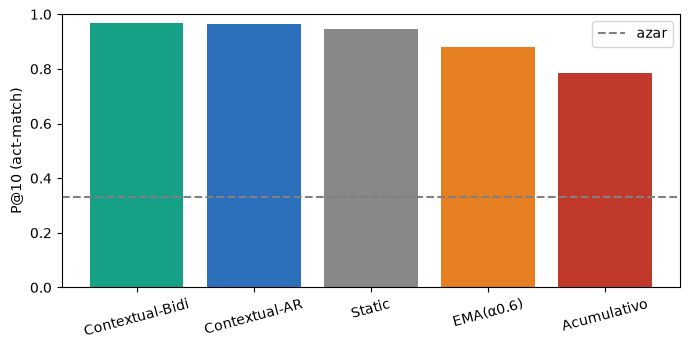

In [5]:
import matplotlib.pyplot as plt
plot = tab[tab["representación"] != "Random (piso)"].set_index("representación")
colors = {"Static": "#888", "Acumulativo": "#c0392b", "EMA(α0.6)": "#e67e22",
          "Contextual-AR": "#2c6fbb", "Contextual-Bidi": "#16a085"}
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.bar(plot.index, plot["P@10"], color=[colors[i] for i in plot.index])
ax.axhline(float(tab.set_index("representación").loc["Random (piso)", "P@10"]),
           ls="--", c="gray", label="azar")
ax.set_ylabel("P@10 (act-match)"); ax.set_ylim(0, 1); ax.legend()
plt.xticks(rotation=15); plt.tight_layout(); plt.show()

**Lectura.** Los contextuales (AR/Bidi) quedan **primeros**: preservan la función comunicativa del
turno mejor que Static, y mucho mejor que cumulativo/EMA (que la *borronean* al promediar el
historial). Pero el acto es casi **intrínseco al turno** → esta métrica favorece quedarse cerca del
`e_t` de D2F y **no** testea contexto de *situación*. Eso lo mide el notebook 02.